In [1]:
import kagglehub

path = kagglehub.dataset_download(
    "vjchoudhary7/customer-segmentation-tutorial-in-python"
)

print("Dataset path:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Dataset path: /kaggle/input/customer-segmentation-tutorial-in-python


In [3]:
import os

os.listdir(path)

['Mall_Customers.csv']

In [4]:
import pandas as pd

data = pd.read_csv(
    os.path.join(path, "Mall_Customers.csv")
)

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
data.shape

(200, 5)

In [6]:
data.columns.tolist()

['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [12]:
data.duplicated().sum()

np.int64(0)

In [13]:
import numpy as np

categorical_features = data.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = data.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Gender']

Numerical Features:
['CustomerID', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [14]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [15]:
data = data.drop(columns=["CustomerID"])

In [16]:
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [17]:
data.isnull().sum()

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [18]:
for col in data.select_dtypes(include=np.number).columns:
    data[col] = data[col].fillna(data[col].median())

In [19]:
for col in data.select_dtypes(include="object").columns:
    data[col] = data[col].fillna(data[col].mode()[0])

In [20]:
data["Gender"].value_counts()

,count
Gender,
Female,112
Male,88


In [21]:
data["Gender"] = data["Gender"].map({
    "Male": 0,
    "Female": 1
})

In [22]:
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [23]:
data.dtypes

,0
Gender,int64
Age,int64
Annual Income (k$),int64
Spending Score (1-100),int64


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(data)

In [25]:
scaled_data[:5]

array([[-1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [-1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [ 0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [ 0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [ 0.88640526, -0.56336851, -1.66266033, -0.39597992]])

In [26]:
scaled_df = pd.DataFrame(
    scaled_data,
    columns=data.columns
)

scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


In [27]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [28]:
inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    inertia.append(kmeans.inertia_)

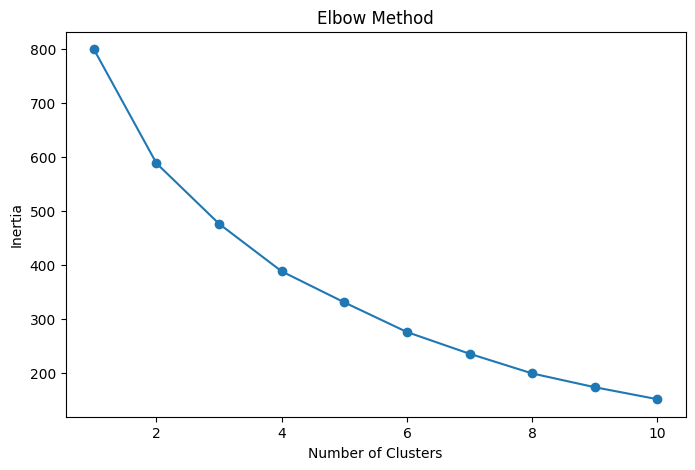

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [30]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_data)

In [31]:
data["Cluster"] = clusters

In [32]:
data.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,0,19,15,39,1
1,0,21,15,81,1
2,1,20,16,6,0
3,1,23,16,77,2
4,1,31,17,40,0


In [33]:
data["Cluster"].value_counts().sort_index()

,count
Cluster,
0,56
1,46
2,56
3,42


In [34]:
cluster_profile = data.groupby("Cluster").mean()

cluster_profile

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,1.0,47.803571,58.071429,34.875000
1,0.0,28.000000,62.239130,64.826087
2,1.0,28.392857,60.428571,68.178571
3,0.0,52.738095,62.214286,30.642857


In [35]:
data.groupby("Cluster")[
    ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
].mean().round(2)

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,47.80,58.07,34.88
1,28.00,62.24,64.83
2,28.39,60.43,68.18
3,52.74,62.21,30.64


In [36]:
data.groupby("Cluster").size()

,0
Cluster,
0,56
1,46
2,56
3,42


In [37]:
profile = data.groupby("Cluster").agg({
    "Age": "mean",
    "Annual Income (k$)": "mean",
    "Spending Score (1-100)": "mean"
}).round(2)

profile["Customer Count"] = data.groupby("Cluster").size()

profile

,Age,Annual Income (k$),Spending Score (1-100),Customer Count
Cluster,,,,
0,47.80,58.07,34.88,56
1,28.00,62.24,64.83,46
2,28.39,60.43,68.18,56
3,52.74,62.21,30.64,42


In [38]:
data.groupby("Cluster")["Gender"].mean().round(2)

,Gender
Cluster,
0,1.0
1,0.0
2,1.0
3,0.0


In [39]:
from sklearn.decomposition import PCA

In [40]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [41]:
pca_data[:5]

array([[-0.40638272, -0.52071363],
       [-1.42767287, -0.3673102 ],
       [ 0.05076057, -1.89406774],
       [-1.6945131 , -1.63190805],
       [-0.31310838, -1.81048272]])

In [42]:
print("PC1 Explained Variance:",
      pca.explained_variance_ratio_[0])

print("PC2 Explained Variance:",
      pca.explained_variance_ratio_[1])

print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

PC1 Explained Variance: 0.33690045571012545
PC2 Explained Variance: 0.26230644627185906
Total Explained Variance: 0.5992069019819846


In [43]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = clusters

pca_df.head()

,PC1,PC2,Cluster
0,-0.406383,-0.520714,1
1,-1.427673,-0.367310,1
2,0.050761,-1.894068,0
3,-1.694513,-1.631908,2
4,-0.313108,-1.810483,0


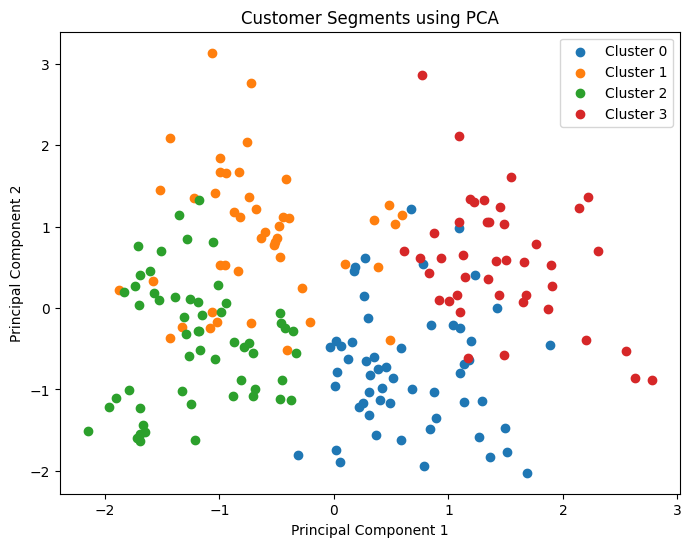

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

for cluster in range(4):
    cluster_data = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        label=f"Cluster {cluster}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segments using PCA")
plt.legend()

plt.show()

In [45]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nPC1:", pca.explained_variance_ratio_[0])
print("PC2:", pca.explained_variance_ratio_[1])

print("\nTotal Explained Variance:",
      pca.explained_variance_ratio_.sum())

Explained Variance Ratio:
[0.33690046 0.26230645]

PC1: 0.33690045571012545
PC2: 0.26230644627185906

Total Explained Variance: 0.5992069019819846


In [46]:
data.groupby("Cluster")["Gender"].mean().round(2)

,Gender
Cluster,
0,1.0
1,0.0
2,1.0
3,0.0


## Cluster Profiling

### Cluster 0 – Mature Female Low Spenders
- Average Age: 47.80
- Average Income: 58.07k
- Spending Score: 34.88
- Customers: 56
- Gender: Female

Mature female customers with moderate income but relatively low spending.

### Cluster 1 – Young Male Active Spenders
- Average Age: 28.00
- Average Income: 62.24k
- Spending Score: 64.83
- Customers: 46
- Gender: Male

Young male customers with relatively high income and spending activity.

### Cluster 2 – Young Female High Spenders
- Average Age: 28.39
- Average Income: 60.43k
- Spending Score: 68.18
- Customers: 56
- Gender: Female

Young female customers with the highest average spending score.

### Cluster 3 – Mature Male Low Spenders
- Average Age: 52.74
- Average Income: 62.21k
- Spending Score: 30.64
- Customers: 42
- Gender: Male

Older male customers with moderate-to-high income but low spending.

## PCA Analysis

PCA was used to reduce the scaled features to two dimensions for visualization.

- PC1 Explained Variance: 33.69%
- PC2 Explained Variance: 26.23%
- Total Explained Variance: 59.92%

The PCA plot shows four distinguishable customer segments with some overlap. The two principal components retain about 59.92% of the original variance.

## Business Recommendations

- **Cluster 0:** Use discounts, loyalty rewards, and personalized promotions to increase spending.
- **Cluster 1:** Target with new products, premium offers, and loyalty programs.
- **Cluster 2:** Focus on premium products, exclusive launches, and personalized recommendations.
- **Cluster 3:** Use value-oriented promotions and targeted discounts to improve engagement.


## Key Observations

- Four customer segments were identified using K-Means clustering.
- Younger customers in Clusters 1 and 2 have higher spending scores.
- Older customers in Clusters 0 and 3 have lower spending scores.
- Cluster 2 has the highest average spending score at 68.18.
- Cluster 3 has the lowest average spending score at 30.64.
- PCA retained 59.92% of the total variance using two components.